# Credit Risk StressLab — Master Training Notebook

End-to-end pipeline: localize the German Credit dataset into an Indian context, train an XGBoost default-risk model, save artifacts for a Streamlit app, and run explainability (SHAP) and fairness (Fairlearn) audits.

## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
np.random.seed(42)

## Step 1: Load German Data & Convert to Indian Context

In [2]:
print("Loading and Localizing Data...")
try:
    df = pd.read_csv('Dataset/german_credit_data.csv').drop('Unnamed: 0', axis=1)
except:
    df = pd.read_csv('german.csv')

housing_map = {'own': 'Self-Owned', 'rent': 'Rented', 'free': 'Family-Owned'}
df['Housing_Type'] = df['Housing'].map(housing_map)

purpose_map = {
    'car': 'Vehicle Loan', 'furniture/equipment': 'Consumer Durable Loan',
    'radio/TV': 'Consumer Durable Loan', 'education': 'Education Loan',
    'business': 'Business Loan', 'repairs': 'Home Renovation Loan'
}
df['Loan_Purpose'] = df['Purpose'].map(purpose_map).fillna('Personal Loan')
job_map = {0: 'Unskilled', 1: 'Unskilled Resident', 2: 'Skilled Employee', 3: 'Highly Skilled'}
df['Employment_Type'] = df['Job'].map(job_map)

Loading and Localizing Data...


In [4]:
# Generate Indian Numerics
def gen_income(row):
    if row['Job'] == 3:
        return np.random.randint(90000, 200000)
    elif row['Job'] == 2:
        return np.random.randint(40000, 100000)
    else:
        return np.random.randint(15000, 45000)

df['Monthly_Income_INR'] = df.apply(gen_income, axis=1)

df['Loan_Amount_INR'] = df['Credit amount'] * 50

df['Existing_EMI_INR'] = (
    df['Monthly_Income_INR'] *
    np.random.uniform(0.15, 0.45, size=len(df))
).astype(int)

# Realistic CIBIL Score (Bell Curve)
df['CIBIL_Score'] = np.random.normal(
    loc=720,
    scale=80,
    size=len(df)
).astype(int)

# Keep CIBIL within realistic range
df['CIBIL_Score'] = df['CIBIL_Score'].clip(300, 900)

In [5]:
# Probabilistic Target (The Magic Fix for realistic AUC)
def calculate_default(row):
    emi_ratio = row['Existing_EMI_INR'] / row['Monthly_Income_INR']
    if row['CIBIL_Score'] < 650 and emi_ratio > 0.35:
        return np.random.choice([0, 1], p=[0.15, 0.85])
    elif row['CIBIL_Score'] < 650 or emi_ratio > 0.35:
        return np.random.choice([0, 1], p=[0.60, 0.40])
    else:
        return np.random.choice([0, 1], p=[0.95, 0.05])

df['Is_Default'] = df.apply(calculate_default, axis=1)

In [6]:
final_df = df[[
    'Age', 'Sex', 'Employment_Type', 'Monthly_Income_INR', 
    'Existing_EMI_INR', 'CIBIL_Score', 'Loan_Amount_INR', 
    'Loan_Purpose', 'Housing_Type', 'Duration', 'Is_Default'
]].rename(columns={'Duration': 'Loan_Tenure_Months'})

# Save Final Indian Dataset for GitHub/Reference
final_df.to_csv('Indian_Credit_Risk_Dataset.csv', index=False)
print("✅ Indian Dataset Created and Saved.")
final_df.head()

✅ Indian Dataset Created and Saved.


,Age,Sex,Employment_Type,Monthly_Income_INR,Existing_EMI_INR,CIBIL_Score,Loan_Amount_INR,Loan_Purpose,Housing_Type,Loan_Tenure_Months,Is_Default
0,67,male,Skilled Employee,55254,8866,900,58450,Consumer Durable Loan,Self-Owned,6,0
1,22,female,Skilled Employee,84238,35251,782,297550,Consumer Durable Loan,Self-Owned,48,1
2,49,male,Unskilled Resident,16252,6631,765,104800,Education Loan,Self-Owned,12,1
3,45,male,Skilled Employee,79764,22910,800,394100,Consumer Durable Loan,Family-Owned,42,0
4,53,male,Skilled Employee,52173,13948,669,243500,Vehicle Loan,Family-Owned,24,0


## Step 2: Preprocessing & Model Training

In [7]:
print("\nTraining XGBoost Model...")
X = final_df.drop('Is_Default', axis=1)
y = final_df['Is_Default']
original_sex = X['Sex'] 

X_train, X_test, y_train, y_test, sex_train, sex_test = train_test_split(
    X, y, original_sex, test_size=0.2, random_state=42, stratify=y
)


Training XGBoost Model...


In [8]:
cat_cols = ['Sex', 'Employment_Type', 'Loan_Purpose', 'Housing_Type']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [10]:
ratio = (len(y_train) - sum(y_train)) / sum(y_train)
model = xgb.XGBClassifier(n_estimators=150, learning_rate=0.05, max_depth=4, scale_pos_weight=ratio, random_state=42)
model.fit(X_train_proc, y_train)

y_pred_probs = model.predict_proba(X_test_proc)[:, 1]
y_pred = (y_pred_probs > 0.5).astype(int)

print(f"✅ ROC-AUC Score: {roc_auc_score(y_test, y_pred_probs):.4f}")

✅ ROC-AUC Score: 0.7703


## Step 3: Save Model & Preprocessor 

In [11]:
joblib.dump(model, 'xgb_credit_model.pkl')
joblib.dump(preprocessor, 'ohe_preprocessor.pkl')
print("✅ Model & Preprocessor saved as .pkl files!")

✅ Model & Preprocessor saved as .pkl files!


## Step 4: Visualizations

### Viz 1: Confusion Matrix

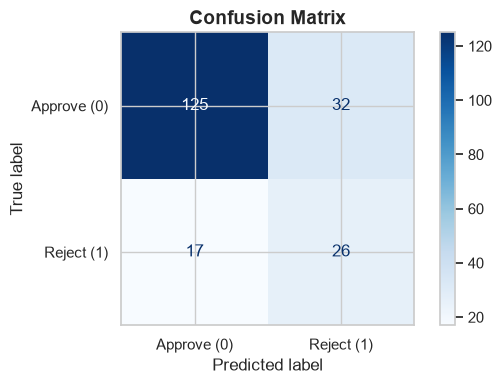

In [12]:
feature_names = preprocessor.get_feature_names_out()
clean_features = [name.replace("cat__", "").replace("remainder__", "") for name in feature_names]

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Approve (0)", "Reject (1)"], cmap='Blues', ax=ax, values_format='d')
ax.set_title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Viz 2: SHAP Beeswarm (Global)

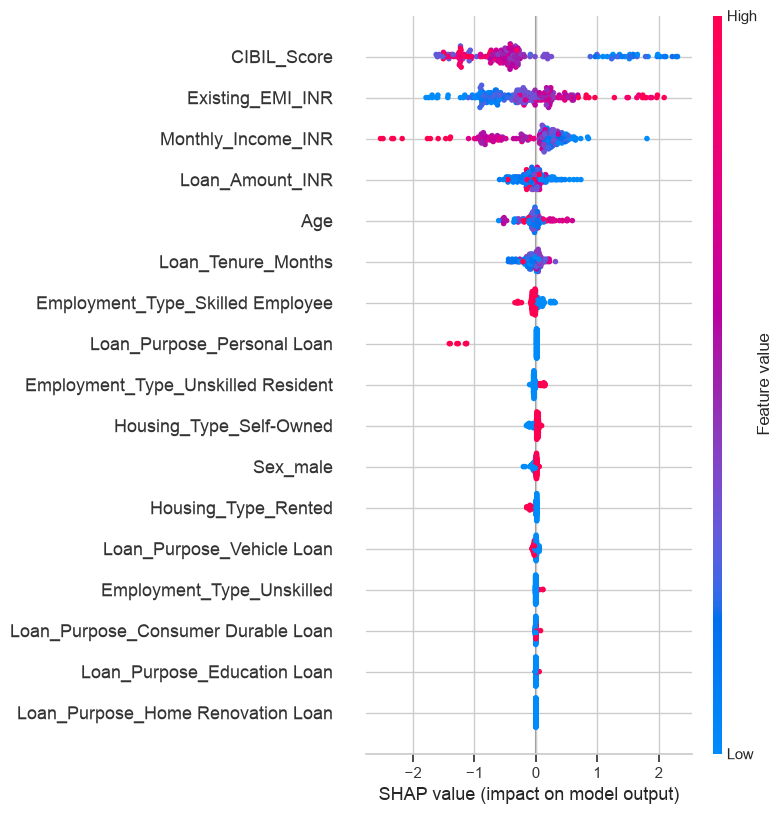

In [13]:
shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_proc)

plt.figure()
shap.summary_plot(shap_values, X_test_proc, feature_names=clean_features)

### Viz 3: SHAP Waterfall (Individual)

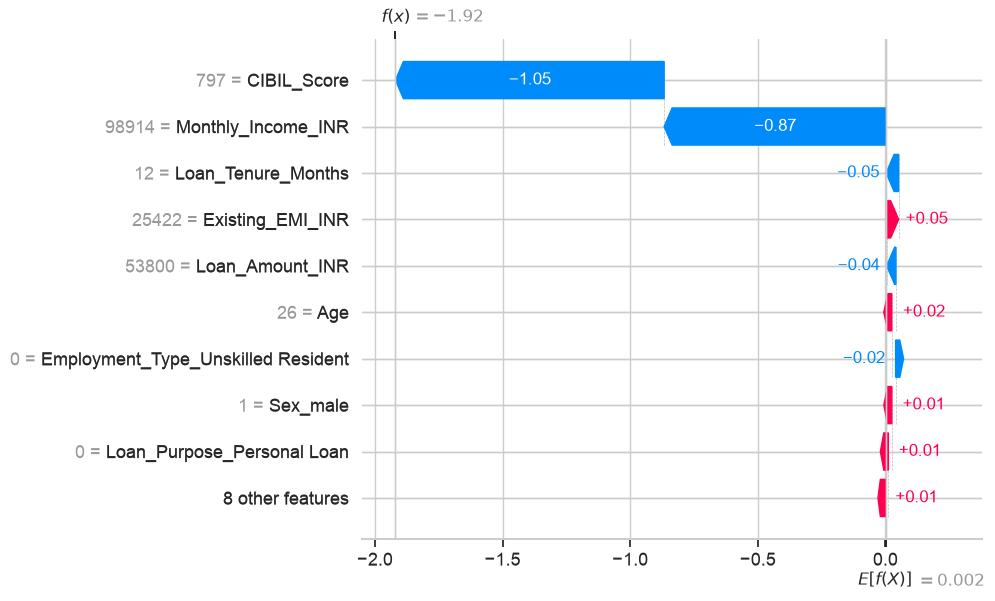

In [14]:
user_index = 0 
explanation = shap.Explanation(
    values=shap_values[user_index], 
    base_values=explainer.expected_value, 
    data=X_test_proc[user_index], 
    feature_names=clean_features
)
shap.plots.waterfall(explanation)

### Viz 4: Fairness Audit

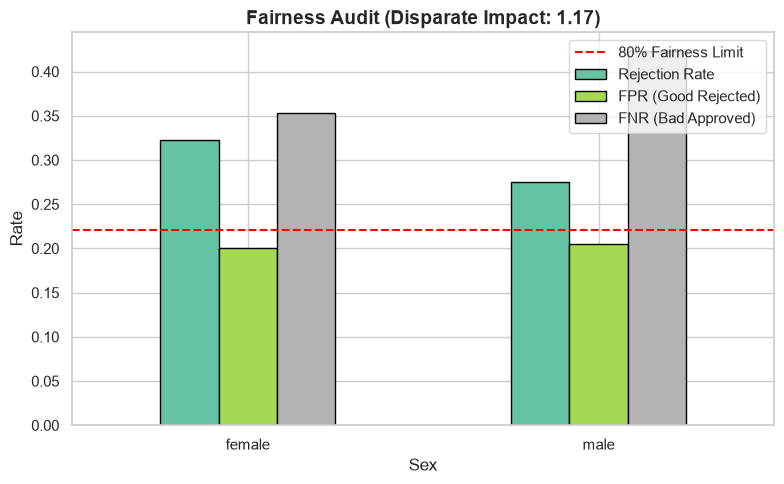

In [15]:
metrics = {'Rejection Rate': selection_rate, 'FPR (Good Rejected)': false_positive_rate, 'FNR (Bad Approved)': false_negative_rate}
fairness_frame = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=sex_test)

female_rej = fairness_frame.by_group.loc['female', 'Rejection Rate']
male_rej = fairness_frame.by_group.loc['male', 'Rejection Rate']
di_ratio = female_rej / male_rej if male_rej != 0 else 0

fig, ax = plt.subplots(figsize=(8, 5))
fairness_frame.by_group.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title(f"Fairness Audit (Disparate Impact: {di_ratio:.2f})", fontsize=14, fontweight='bold')
ax.set_ylabel("Rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.axhline(y=0.8 * male_rej, color='red', linestyle='--', label='80% Fairness Limit')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
print("\n--- FAIRNESS TABLE ---")
print(fairness_frame.by_group)
print(f"\nDisparate Impact Ratio: {di_ratio:.2f} ({'FAIR' if 0.8 <= di_ratio <= 1.25 else 'BIASED'})")


--- FAIRNESS TABLE ---
        Rejection Rate  FPR (Good Rejected)  FNR (Bad Approved)
Sex                                                            
female        0.322581             0.200000            0.352941
male          0.275362             0.205357            0.423077

Disparate Impact Ratio: 1.17 (FAIR)
